## Problem 3: How many people live near shopping centers? (10 points)

In the last step of this analysis, use a *spatial join* to relate data from a population grid data set to the buffer layer created in *problem 2* to find out how many people live in all population grid cells that are **within** 1.5 km distance from each shopping centre. 

Use the same population grid data set as during [lesson 3](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-3/spatial-join.html) (load it directly from WFS, don’t forget to assign a CRS).


*Feel free to divide your solution into more codeblocks than prepared! Remember to add comments to your code :)*

### a) Load the population grid data set and the buffer geometries (2 points)

Use the same population grid data set as during [lesson 3](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-3/spatial-join.html) (load it directly from WFS, don’t forget to assign a CRS). Load the data into a `GeoDataFrame` called `population_grid`.

(optional) If you want, discard unneeded columns and translate the remaining column names from Finnish to English.

In [1]:
# import libraries
import pathlib
import ssl
import geopandas

# Data Directory and Notebook Path
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"

# Load population grid
ssl._create_default_https_context = ssl._create_unverified_context

population_grid = geopandas.read_file(
    "https://kartta.hsy.fi/geoserver/wfs"
    "?service=wfs"
    "&version=2.0.0"
    "&request=GetFeature"
    "&typeName=asuminen_ja_maankaytto:Vaestotietoruudukko_2020"
    "&srsName=EPSG:3879"
)

population_grid.set_crs("EPSG:3879", inplace=True)  # for WFS data, the CRS needs to be specified manually

,gml_id,index,asukkaita,asvaljyys,ika0_9,ika10_19,ika20_29,ika30_39,ika40_49,ika50_59,ika60_69,ika70_79,ika_yli80,geometry
0,Vaestotietoruudukko_2020.1,703,5,51,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6685998.998, 25472499.9..."
1,Vaestotietoruudukko_2020.2,710,8,44,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6684249.004, 25472499.9..."
2,Vaestotietoruudukko_2020.3,711,5,90,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6683999.005, 25472499.9..."
3,Vaestotietoruudukko_2020.4,715,13,34,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6682998.998, 25472499.9..."
4,Vaestotietoruudukko_2020.5,848,5,53,99,99,99,99,99,99,99,99,99,"POLYGON ((25472749.993 6690249.003, 25472749.9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5832,Vaestotietoruudukko_2020.5833,27108,7,70,99,99,99,99,99,99,99,99,99,"POLYGON ((25513249.999 6686248.997, 25513249.9..."
5833,Vaestotietoruudukko_2020.5834,27109,6,38,99,99,99,99,99,99,99,99,99,"POLYGON ((25513249.999 6685998.998, 25513249.9..."
5834,Vaestotietoruudukko_2020.5835,27110,14,23,99,99,99,99,99,99,99,99,99,"POLYGON ((25513249.999 6685748.999, 25513249.9..."
5835,Vaestotietoruudukko_2020.5836,27111,12,59,99,99,99,99,99,99,99,99,99,"POLYGON ((25513249.999 6685499.000, 25513249.9..."


In [2]:
# NON-EDITABLE CODE CELL FOR TESTING YOUR SOLUTION
import geopandas
import pyproj

assert isinstance(population_grid, geopandas.GeoDataFrame)
assert population_grid.crs == pyproj.CRS("EPSG:3879")



Load the buffers computed in *problem 2* into a `GeoDataFrame` called `shopping_centre_buffers`. Add an `assert` statement to check whether the two data frames are in the same CRS.

<AxesSubplot: >

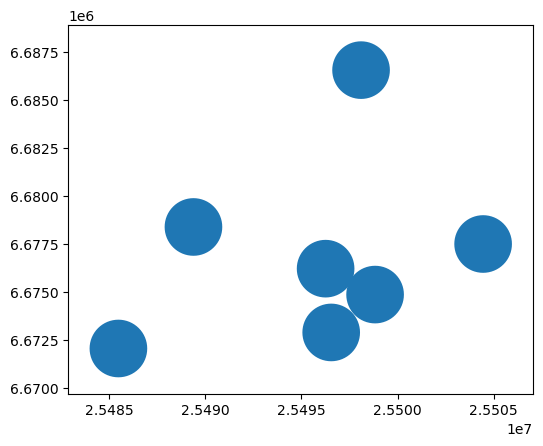

In [3]:
# Read file
shopping_centre_buffers = geopandas.read_file(
    DATA_DIRECTORY / "shopping_centres.gpkg",
    layer = "buffers"
)

shopping_centre_buffers.plot()

In [4]:
# NON-EDITABLE CODE CELL FOR TESTING YOUR SOLUTION
assert isinstance(shopping_centre_buffers, geopandas.GeoDataFrame)
assert shopping_centre_buffers.geometry.geom_type.unique() == ["Polygon"]
assert shopping_centre_buffers.crs == pyproj.CRS("EPSG:3879")


---

### b) Carry out a *spatial join* between the `population_grid` and the `shopping_centre_buffers`  (4 points)

Join the shopping centre’s `id` column (and others, if you want) to the population grid data frame, for all population grid cells that are **within** the buffer area of each shopping centre. [Use a *join-type* that retains only rows from both input data frames for which the geometric predicate is true](https://geopandas.org/en/stable/gallery/spatial_joins.html#Types-of-spatial-joins). 


In [5]:
# Spatialjoin
population_in_buffers = population_grid.sjoin(
    shopping_centre_buffers,
    how = "inner",
    predicate = "within"
)

In [6]:
population_in_buffers.head()

,gml_id,index,asukkaita,asvaljyys,ika0_9,ika10_19,ika20_29,ika30_39,ika40_49,ika50_59,ika60_69,ika70_79,ika_yli80,geometry,index_right,id,name,addr
1147,Vaestotietoruudukko_2020.1148,8371,128,52,15,25,4,7,32,16,19,9,1,"POLYGON ((25484250.000 6672499.005, 25484250.0...",2,1002,Iso-omena,"Piispansilta 11, 02230 Espoo, Finland"
1148,Vaestotietoruudukko_2020.1149,8372,81,57,99,99,99,99,99,99,99,99,99,"POLYGON ((25484250.000 6672249.006, 25484250.0...",2,1002,Iso-omena,"Piispansilta 11, 02230 Espoo, Finland"
1149,Vaestotietoruudukko_2020.1150,8374,20,61,99,99,99,99,99,99,99,99,99,"POLYGON ((25484250.000 6671748.997, 25484250.0...",2,1002,Iso-omena,"Piispansilta 11, 02230 Espoo, Finland"
1211,Vaestotietoruudukko_2020.1212,8532,110,50,14,20,2,10,15,24,7,15,3,"POLYGON ((25484499.998 6672749.004, 25484499.9...",2,1002,Iso-omena,"Piispansilta 11, 02230 Espoo, Finland"
1212,Vaestotietoruudukko_2020.1213,8533,136,53,18,28,7,10,25,21,15,11,1,"POLYGON ((25484499.998 6672499.005, 25484499.9...",2,1002,Iso-omena,"Piispansilta 11, 02230 Espoo, Finland"


In [7]:
population_in_buffers.crs

<Derived Projected CRS: EPSG:3879>
Name: ETRS89 / GK25FIN
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Finland - nominally onshore between 24°30'E and 25°30'E but may be used in adjacent areas if a municipality chooses to use one zone over its whole extent.
- bounds: (24.5, 59.94, 25.5, 68.9)
Coordinate Operation:
- name: Finland Gauss-Kruger zone 25
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<AxesSubplot: >

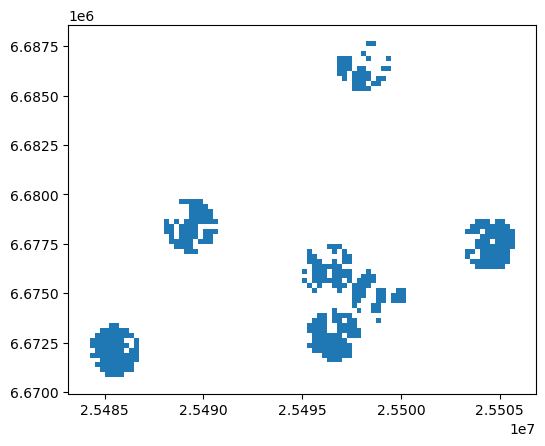

In [8]:
population_in_buffers.plot()


---

### c) Compute the population sum around shopping centres (4 points)

Group the resulting (joint) data frame by shopping centre (`id` or `name`), and calculate the `sum()` of the population living inside the 1.5 km radius around them.

Print the results, for instance, in the form "12345 people live within 1.5 km from REDI".

In [9]:
# ADD YOUR OWN CODE HERE


In [10]:
population_sum = (
    population_in_buffers
    .groupby(["id", "name"])["asukkaita"]
    .sum()
    .reset_index()
)

# Print results
for _, row in population_sum.iterrows():
    print(f"{row['asukkaita']} people live within 1.5 km from {row['name']}.")

19514 people live within 1.5 km from Itis.
56099 people live within 1.5 km from Forum.
26698 people live within 1.5 km from Iso-omena.
24173 people live within 1.5 km from Sello.
10956 people live within 1.5 km from Jumbo.
27801 people live within 1.5 km from REDI.
21778 people live within 1.5 km from Tripla.



---

### d) Reflection

Good job! You are almost done with this week’s exercise. Please quickly answer the following short questions:
    
- How challenging did you find problems 1-3 (on scale to 1-5), and why?
- What was easy?
- What was difficult?

Add your answers in a new *Markdown* cell below: